In [1]:
import pandas as pd

In [2]:
df=pd.read_excel('data/Raisin_Dataset.xlsx')
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [3]:
from sklearn.model_selection import train_test_split
x=df.drop('Class',axis=1)
y=df['Class']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

<h1>SVM model training, kernal: no scaling</h1>

In [4]:
from sklearn.svm import SVC
model=SVC(kernel='rbf')
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [5]:
model.n_iter_ #kernel='rbf', iteration is 225

array([225], dtype=int32)

<h2>kernal: linear</h2>

In [6]:
model1=SVC(kernel='linear')
model1.fit(x_train,y_train)
y_pred1=model1.predict(x_test)

In [7]:
model1.n_iter_ #kernel='linear', iteration is 292224717

array([292224717], dtype=int32)

<h1>Performance of models with different parameter</h1>

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

In [9]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       Besni       0.88      0.79      0.83        86
     Kecimen       0.83      0.90      0.86        94

    accuracy                           0.85       180
   macro avg       0.85      0.85      0.85       180
weighted avg       0.85      0.85      0.85       180



In [10]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[68 18]
 [ 9 85]]


<Axes: >

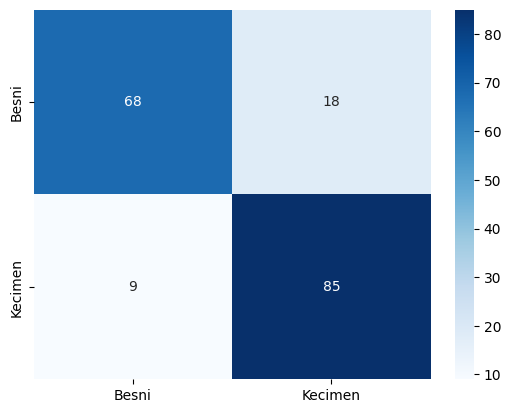

In [11]:
import seaborn as sns
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=model.classes_,yticklabels=model.classes_)

In [12]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

       Besni       0.82      0.90      0.86        86
     Kecimen       0.90      0.82      0.86        94

    accuracy                           0.86       180
   macro avg       0.86      0.86      0.86       180
weighted avg       0.86      0.86      0.86       180



In [13]:
cm1=confusion_matrix(y_test,y_pred1)
print(cm1)

[[77  9]
 [17 77]]


<Axes: >

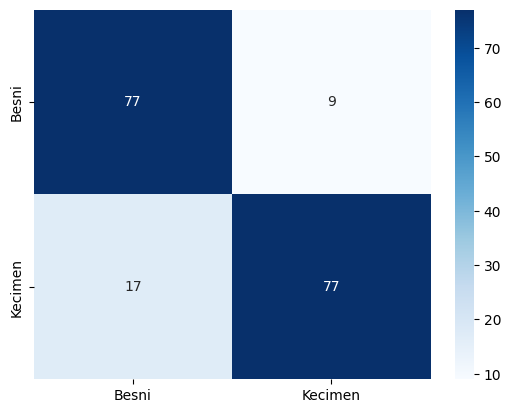

In [14]:
sns.heatmap(cm1,annot=True,fmt='d',cmap='Blues',xticklabels=model1.classes_,yticklabels=model1.classes_)

<h1>SVM model training with scaling (data preprossing)</h1>

In [15]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler=StandardScaler()
scaler.fit(x)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [18]:
x_train_scaler=scaler.transform(x_train)
x_test_scaler=scaler.transform(x_test)

In [19]:
x_train_scaler

array([[-0.18899551,  0.15973552, -0.44359745, ..., -0.16507106,
        -0.47292075,  0.03800403],
       [-0.39304658, -0.83221359,  0.56429389, ..., -0.39858728,
         0.12485132, -0.41572577],
       [-0.05297857, -0.43596873,  0.67588606, ..., -0.10145844,
         1.17225654, -0.26069978],
       ...,
       [ 2.02280624,  1.52682193,  1.90489827, ...,  1.91117405,
         1.01069031,  1.49210229],
       [-1.52866749, -1.59978989, -2.08647336, ..., -1.49386793,
        -1.44493478, -1.76491643],
       [-0.76951747, -1.04300791, -0.26263666, ..., -0.79103687,
         0.20282377, -0.92850265]], shape=(720, 7))

<h2>training the model with scaled data</h2>

In [20]:
model2=SVC(kernel='rbf')
model2.fit(x_train_scaler,y_train)
y_pred2=model2.predict(x_test_scaler)

In [21]:
report=classification_report(y_test,y_pred2)
print(report)

              precision    recall  f1-score   support

       Besni       0.86      0.81      0.84        86
     Kecimen       0.84      0.88      0.86        94

    accuracy                           0.85       180
   macro avg       0.85      0.85      0.85       180
weighted avg       0.85      0.85      0.85       180



In [27]:
model2.n_iter_ #No.OF iterations is 363, without scaled data NO.Of iteration was 225,training time redused

array([363], dtype=int32)

In [25]:
model3=SVC(kernel='rbf')
model3.fit(x_train_scaler,y_train)
y_pred3=model3.predict(x_test_scaler)
report=classification_report(y_test,y_pred2)
print(report)

              precision    recall  f1-score   support

       Besni       0.86      0.81      0.84        86
     Kecimen       0.84      0.88      0.86        94

    accuracy                           0.85       180
   macro avg       0.85      0.85      0.85       180
weighted avg       0.85      0.85      0.85       180



In [ ]:
model3.n_iter_ #No.OF iterations is 363, without scaled data NO.Of iteration was 292224717

array([363], dtype=int32)